# Домашнее задание № 2. Блок 2. Вариант 10

**Тема**: Численные методы безусловной оптимизации функции нескольких переменных

**Исходные данные**:

### Для ДЗ2.1 и ДЗ2.3 (вариант 10):
$$f(x_1, x_2) = 3x_1^2 + 2x_1x_2 + 4x_2^2 + 12x_1 + 26x_2 + 45$$
$$x^0 = (2, 4)$$
$$x^* = (-1, -3)$$

### Для ДЗ2.2 (вариант 10):
$$z(x, y) = x^3 - 9x^2 + 24x + y^3 - 14y^2 + 64y - 116$$
$$x_0 = (3.5, 5.5)$$
$$\varepsilon = 0.0001$$

In [1]:
from abc import ABCMeta, abstractmethod
from typing import Tuple, List, Dict
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 9)

In [2]:
class MathematicalFunction(metaclass=ABCMeta):
    @abstractmethod
    def __call__(self, x: NDArray[np.float64]) -> float:
        ...
    
    @abstractmethod
    def gradient(self, x: NDArray[np.float64]) -> NDArray[np.float64]:
        ...
    
    @abstractmethod
    def hessian(self, x: NDArray[np.float64]) -> NDArray[np.float64]:
        ...
    
    @property
    @abstractmethod
    def name(self) -> str:
        ...

In [3]:
class OptimizationHistory:
    def __init__(self) -> None:
        self.x_history: List[NDArray[np.float64]] = []
        self.f_history: List[float] = []
        self.grad_history: List[NDArray[np.float64]] = []
        self.iterations: int = 0
    
    def add_point(
            self,
            x: NDArray[np.float64],
            f_val: float, 
            grad: NDArray[np.float64]
        ) -> None:
        self.x_history.append(x.copy())
        self.f_history.append(f_val)
        self.grad_history.append(grad.copy())
        self.iterations += 1
    
    def get_final_point(self) -> NDArray[np.float64]:
        if self.x_history:
            return self.x_history[-1]
        return np.array([], dtype=np.float64)
    
    def get_history_array(self) -> NDArray[np.float64]:
        """Получить историю в виде массива"""
        return np.array(self.x_history, dtype=np.float64)

In [4]:
class OptimizationMethod(metaclass=ABCMeta):
    def __init__(self, eps: float = 1e-6, max_iterations: int = 100) -> None:
        self.eps: float = eps
        self.max_iterations: int = max_iterations
        self.history: OptimizationHistory = OptimizationHistory()
    
    @abstractmethod
    def __call__(self, func: MathematicalFunction, 
                 x0: NDArray[np.float64]) -> OptimizationHistory:
        ...
    
    @property
    @abstractmethod
    def name(self) -> str:
        ...

## ДЗ2.1: Визуализация линий уровня и последовательности приближений

In [5]:
class Func1(MathematicalFunction):
    """
    Реализация квадратичной функции двух переменных
    f(x1, x2) = 3*x1^2 + 2*x1*x2 + 4*x2^2 + 12*x1 + 26*x2 + 45
    """
    
    def __call__(self, x: NDArray[np.float64]) -> float:
        x1: float = float(x[0])
        x2: float = float(x[1])
        return 3*x1**2 + 2*x1*x2 + 4*x2**2 + 12*x1 + 26*x2 + 45
    
    def gradient(self, x: NDArray[np.float64]) -> NDArray[np.float64]:
        """Градиент: df/dx1 = 6*x1 + 2*x2 + 12; df/dx2 = 2*x1 + 8*x2 + 26"""
        x1: float = float(x[0])
        x2: float = float(x[1])
        df_dx1: float = 6*x1 + 2*x2 + 12
        df_dx2: float = 2*x1 + 8*x2 + 26
        return np.array([df_dx1, df_dx2], dtype=np.float64)
    
    def hessian(self, x: NDArray[np.float64]) -> NDArray[np.float64]:
        """Матрица Гессе: [[6, 2], [2, 8]]"""
        return np.array([[6, 2], [2, 8]], dtype=np.float64)
    
    @property
    def name(self) -> str:
        return "Квадратичная функция (вариант 10)"

In [6]:
class CoordinateDescentMethod(OptimizationMethod):
    def __call__(
            self,
            func: MathematicalFunction, 
            x0: NDArray[np.float64]
        ) -> OptimizationHistory:
        x: NDArray[np.float64] = np.array(x0, dtype=np.float64)
        self.history = OptimizationHistory()
        
        f_val: float = func(x)
        grad: NDArray[np.float64] = func.gradient(x)
        self.history.add_point(x, f_val, grad)
        
        for _ in range(self.max_iterations):
            x_old: NDArray[np.float64] = x.copy()
            
            alpha: float = 0.01
            for i in range(len(x)):
                grad = func.gradient(x)
                x[i] = x[i] - alpha * grad[i]
                f_val = func(x)
                grad_new: NDArray[np.float64] = func.gradient(x)
                self.history.add_point(x, f_val, grad_new)
            
            if np.linalg.norm(x - x_old) < self.eps:
                break
        
        return self.history
    
    @property
    def name(self) -> str:
        return "Покоординатный спуск"

In [7]:
class GradientDescentMethod(OptimizationMethod):
    def __init__(
            self,
            alpha: float = 0.05,
            eps: float = 1e-6, 
            max_iterations: int = 100
        ) -> None:
        super().__init__(eps, max_iterations)
        self.alpha: float = alpha
    
    def __call__(
            self,
            func: MathematicalFunction, 
            x0: NDArray[np.float64]
        ) -> OptimizationHistory:
        x: NDArray[np.float64] = np.array(x0, dtype=np.float64)
        self.history = OptimizationHistory()
        
        f_val: float = func(x)
        grad: NDArray[np.float64] = func.gradient(x)
        self.history.add_point(x, f_val, grad)
        
        for _ in range(self.max_iterations):
            grad = func.gradient(x)
            
            if np.linalg.norm(grad) < self.eps:
                break
            
            x = x - self.alpha * grad
            f_val = func(x)
            grad = func.gradient(x)
            self.history.add_point(x, f_val, grad)
        
        return self.history
    
    @property
    def name(self) -> str:
        return "Градиентный спуск"

In [8]:
class SteepestDescentMethod(OptimizationMethod):
    """
    Реализация метода наискорейшего спуска.
    Использует оптимальный шаг: alpha = (g^T g) / (g^T H g)
    """
    
    def __call__(
            self,
            func: MathematicalFunction, 
            x0: NDArray[np.float64]
        ) -> OptimizationHistory:
        x: NDArray[np.float64] = np.array(x0, dtype=np.float64)
        self.history = OptimizationHistory()
        
        f_val: float = func(x)
        grad: NDArray[np.float64] = func.gradient(x)
        self.history.add_point(x, f_val, grad)
        
        for _ in range(self.max_iterations):
            grad = func.gradient(x)
            
            if np.linalg.norm(grad) < self.eps:
                break
            
            H: NDArray[np.float64] = func.hessian(x)
            denominator: float = float(grad @ (H @ grad))
            
            if abs(denominator) < 1e-15:
                break
            
            alpha: float = float((grad @ grad) / denominator)
            x = x - alpha * grad
            f_val = func(x)
            grad = func.gradient(x)
            self.history.add_point(x, f_val, grad)
        
        return self.history
    
    @property
    def name(self) -> str:
        return "Наискорейший спуск"

In [9]:
class Visualizer:
    @staticmethod
    def visualize_method(
        history: OptimizationHistory,
        method_name: str, 
        func: MathematicalFunction,
        true_min: list[float] | None = [-1.0, -3.0]
    ) -> None:
        _, ax = plt.subplots(figsize=(10, 9))

        history_array: NDArray[np.float64] = history.get_history_array()
        f_values: NDArray[np.float64] = np.array(history.f_history, dtype=np.float64)

        all_x: NDArray[np.float64] = history_array[:, 0]
        all_y: NDArray[np.float64] = history_array[:, 1]
        x_min: float = float(all_x.min() - 5)
        x_max: float = float(all_x.max() + 5)
        y_min: float = float(all_y.min() - 5)
        y_max: float = float(all_y.max() + 5)

        x_range: NDArray[np.float64] = np.linspace(x_min, x_max, 300, dtype=np.float64)
        y_range: NDArray[np.float64] = np.linspace(y_min, y_max, 300, dtype=np.float64)
        X, Y = np.meshgrid(x_range, y_range)

        Z: NDArray[np.float64] = np.zeros_like(X, dtype=np.float64)
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                point: NDArray[np.float64] = np.array([X[i, j], Y[i, j]], dtype=np.float64)
                Z[i, j] = func(point)

        # Критически важно: удалить дубликаты и отсортировать уровни для избежания ошибки matplotlib
        contour_levels: List[float] = sorted(np.unique([float(v) for v in f_values]).tolist())
        ax.contour(X, Y, Z, levels=contour_levels, colors='blue', alpha=0.6, linewidths=1)
        ax.contourf(X, Y, Z, levels=20, cmap='viridis', alpha=0.3)

        ax.plot(history_array[:, 0], history_array[:, 1], 'r-o', linewidth=2, 
               markersize=6, label=f'{method_name} ({len(history_array)} точек)', zorder=5)
        ax.plot(history_array[0, 0], history_array[0, 1], 'go', markersize=12, 
               label='Начальная точка', zorder=6)
        ax.plot(history_array[-1, 0], history_array[-1, 1], 'r*', markersize=20, 
               label='Конечная точка', zorder=6)
        if true_min is not None:
            ax.plot(true_min[0], true_min[1], 'k*', markersize=20, label=f'Истинный минимум ({true_min[0]}, {true_min[1]})', zorder=7)


        ax.set_xlabel('x1', fontsize=12)
        ax.set_ylabel('x2', fontsize=12)
        ax.set_title(f'f(x1, x2) = 3*x1^2 + 2*x1*x2 + 4*x2^2 + 12*x1 + 26*x2 + 45\n{method_name}', 
                    fontsize=14, fontweight='bold')
        ax.legend(fontsize=10, loc='upper right')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', adjustable='box')

        plt.tight_layout()
        plt.show()

In [10]:
x0: NDArray[np.float64] = np.array([2.0, 4.0], dtype=np.float64)

method_cd: CoordinateDescentMethod = CoordinateDescentMethod(eps=1e-4, max_iterations=100)
method_gd: GradientDescentMethod = GradientDescentMethod(alpha=0.05, eps=1e-4, max_iterations=100)
method_sd: SteepestDescentMethod = SteepestDescentMethod(eps=1e-4, max_iterations=100)

history_cd: OptimizationHistory = method_cd(Func1(), x0)
history_gd: OptimizationHistory = method_gd(Func1(), x0)
history_sd: OptimizationHistory = method_sd(Func1(), x0)

print(f"Покоординатный спуск: {history_cd.iterations} итераций")
print(f"Градиентный спуск: {history_gd.iterations} итераций")
print(f"Наискорейший спуск: {history_sd.iterations} итераций")

Покоординатный спуск: 201 итераций
Градиентный спуск: 42 итераций
Наискорейший спуск: 6 итераций


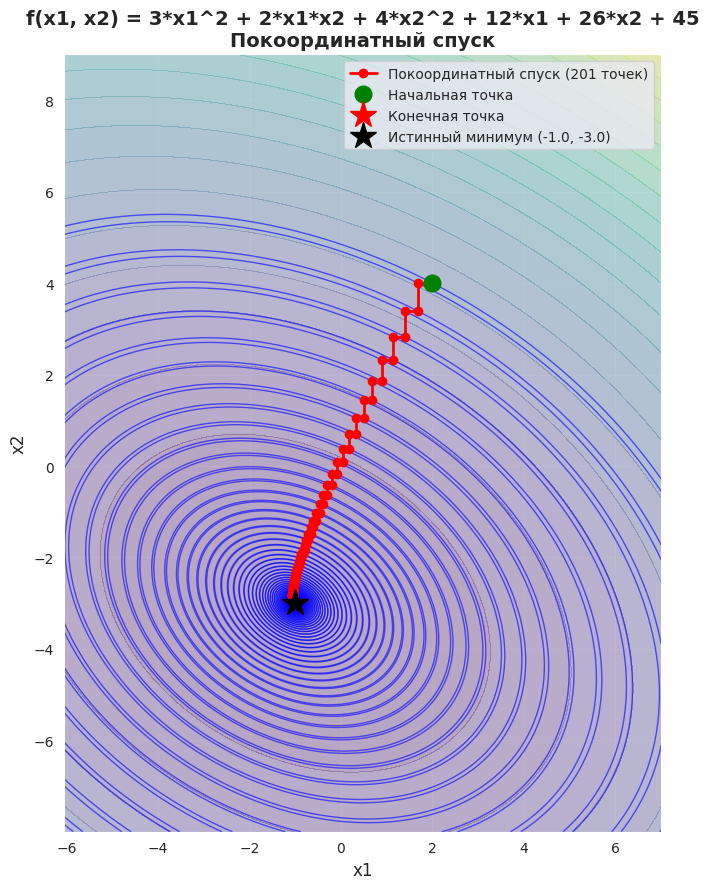

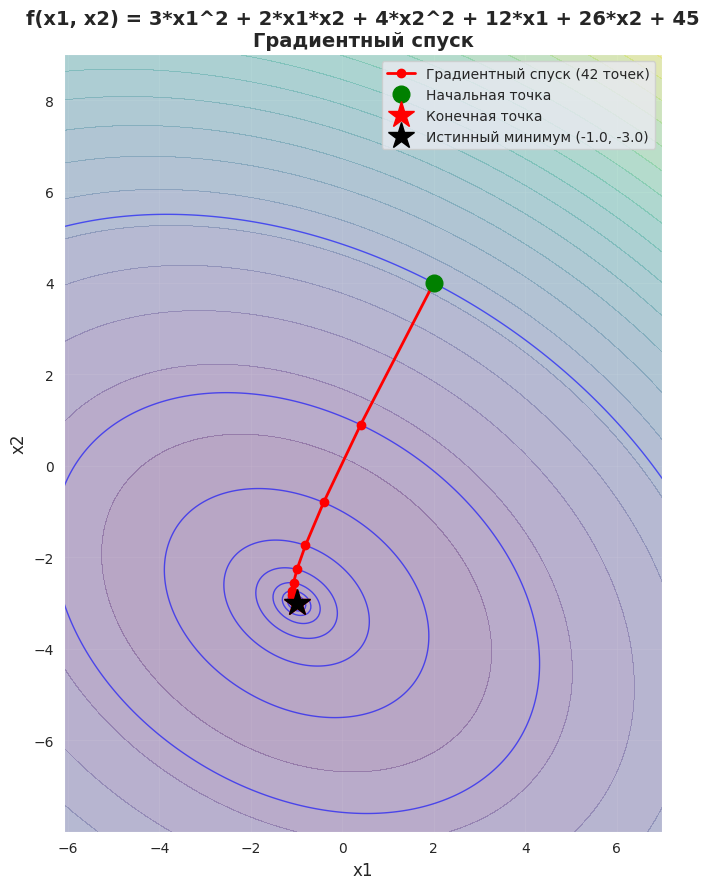

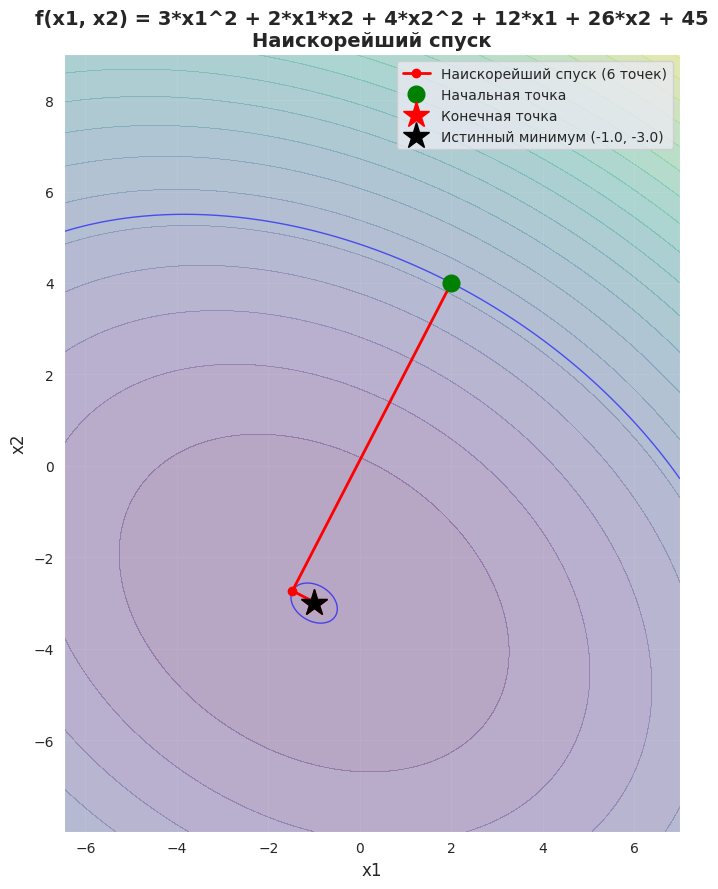

In [11]:
Visualizer.visualize_method(history_cd, method_cd.name, Func1())
Visualizer.visualize_method(history_gd, method_gd.name, Func1())
Visualizer.visualize_method(history_sd, method_sd.name, Func1())

## ДЗ2.2: Метод Ньютона для функции двух переменных

In [12]:
class Func2(MathematicalFunction):
    """
    Кубическая функция двух переменных.
    z(x, y) = x^3 - 9*x^2 + 24*x + y^3 - 14*y^2 + 64*y - 116
    """
    
    def __call__(self, x: NDArray[np.float64]) -> float:
        x_var: float = float(x[0])
        y_var: float = float(x[1])
        return (x_var**3 - 9*x_var**2 + 24*x_var + 
                y_var**3 - 14*y_var**2 + 64*y_var - 116)
    
    def gradient(self, x: NDArray[np.float64]) -> NDArray[np.float64]:
        """
        Градиент:
        dz/dx = 3*x^2 - 18*x + 24
        dz/dy = 3*y^2 - 28*y + 64
        """
        x_var: float = float(x[0])
        y_var: float = float(x[1])
        dz_dx: float = 3*x_var**2 - 18*x_var + 24
        dz_dy: float = 3*y_var**2 - 28*y_var + 64
        return np.array([dz_dx, dz_dy], dtype=np.float64)
    
    def hessian(self, x: NDArray[np.float64]) -> NDArray[np.float64]:
        """
        Матрица Гессе (диагональная):
        h_xx = 6*x - 18
        h_yy = 6*y - 28
        """
        x_var: float = float(x[0])
        y_var: float = float(x[1])
        h_xx: float = 6*x_var - 18
        h_yy: float = 6*y_var - 28
        return np.array([[h_xx, 0], [0, h_yy]], dtype=np.float64)
    
    @property
    def name(self) -> str:
        return "Кубическая функция (ДЗ2.2, вариант 10)"

In [13]:
class NewtonMethod(OptimizationMethod):
    """
    Метод Ньютона для нахождения минимума.
    x_{k+1} = x_k - H^{-1} * grad_f(x_k)
    Критерий остановки: ||grad_f(x_k)|| <= eps
    """
    
    def __call__(
            self,
            func: MathematicalFunction, 
            x0: NDArray[np.float64]
        ) -> OptimizationHistory:
        x: NDArray[np.float64] = np.array(x0, dtype=np.float64)
        self.history = OptimizationHistory()
        
        f_val: float = func(x)
        grad: NDArray[np.float64] = func.gradient(x)
        self.history.add_point(x, f_val, grad)
        
        for k in range(self.max_iterations):
            grad = func.gradient(x)
            grad_norm: float = float(np.linalg.norm(grad))
            
            if grad_norm <= self.eps:
                break
            
            H: NDArray[np.float64] = func.hessian(x)
            det_H: float = float(np.linalg.det(H))
            
            if abs(det_H) < 1e-15:
                break
            
            try:
                H_inv: NDArray[np.float64] = np.linalg.inv(H)
                step: NDArray[np.float64] = H_inv @ grad
                x = x - step
            except Exception as e:
                break
            
            f_val = func(x)
            grad = func.gradient(x)
            self.history.add_point(x, f_val, grad)
        
        final_grad: NDArray[np.float64] = func.gradient(x)
        final_grad_norm: float = float(np.linalg.norm(final_grad))
        
        print(f'Метод Ньютона: x* = ({x[0]:.6f}, {x[1]:.6f}), f(x*) = {f_val:.6f}, ||grad|| = {final_grad_norm:.6e}, итераций: {k + 1}')
        
        return self.history
    
    @property
    def name(self) -> str:
        return "Метод Ньютона"

$$
    \mathbf{x}_{k+1} = \mathbf{x}_k - \mathbf{H}^{-1}(\mathbf{x}_k) \nabla f(\mathbf{x}_k)
$$

$$
    \begin{pmatrix} x_1^{(k+1)} \\ x_2^{(k+1)} \end{pmatrix} = 
    \begin{pmatrix} x_1^{(k)} \\ x_2^{(k)} \end{pmatrix} - 
    \begin{pmatrix} 
    \frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2} \\[1em]
    \frac{\partial^2 f}{\partial x_2 \partial x_1} & \frac{\partial^2 f}{\partial x_2^2}
    \end{pmatrix}^{-1} 
    \begin{pmatrix} 
    \frac{\partial f}{\partial x_1} \\[0.5em] 
    \frac{\partial f}{\partial x_2}
    \end{pmatrix}
$$

In [14]:
print('Частные производные:')
print('dz/dx = 3*x^2 - 18*x + 24 = 3*(x^2 - 6*x + 8) = 3*(x-2)*(x-4)')
print('dz/dy = 3*y^2 - 28*y + 64 = (3*y - 8)*(y - 8)')
print('')
print('Стационарные точки: x in {2, 4}, y in {8/3, 8}')
print('')

critical_points: List[Tuple[float, float]] = [
    (2.0, 8/3),
    (2.0, 8.0),
    (4.0, 8/3),
    (4.0, 8.0)
]

func: MathematicalFunction = Func2()
extremum_info: List[Tuple[Tuple[float, float], str, float]] = []

for point in critical_points:
    x_point: NDArray[np.float64] = np.array(point, dtype=np.float64)
    grad: NDArray[np.float64] = func.gradient(x_point)
    H: NDArray[np.float64] = func.hessian(x_point)
    det_H: float = float(np.linalg.det(H))
    h_xx: float = H[0, 0]
    z_val: float = func(x_point)
    
    extremum_type: str
    if det_H > 0:
        if h_xx > 0:
            extremum_type = "ЛОКАЛЬНЫЙ МИНИМУМ"
        else:
            extremum_type = "ЛОКАЛЬНЫЙ МАКСИМУМ"
    elif det_H < 0:
        extremum_type = "СЕДЛОВАЯ ТОЧКА"
    else:
        extremum_type = "НЕОПРЕДЕЛЁННО"
    
    extremum_info.append((point, extremum_type, z_val))
    
    print(f"Точка: ({point[0]}, {point[1]:.4f}) - {extremum_type}, z = {z_val:.6f}")


Частные производные:
dz/dx = 3*x^2 - 18*x + 24 = 3*(x^2 - 6*x + 8) = 3*(x-2)*(x-4)
dz/dy = 3*y^2 - 28*y + 64 = (3*y - 8)*(y - 8)

Стационарные точки: x in {2, 4}, y in {8/3, 8}

Точка: (2.0, 2.6667) - ЛОКАЛЬНЫЙ МАКСИМУМ, z = -5.925926
Точка: (2.0, 8.0000) - СЕДЛОВАЯ ТОЧКА, z = 32.000000
Точка: (4.0, 2.6667) - СЕДЛОВАЯ ТОЧКА, z = -9.925926
Точка: (4.0, 8.0000) - ЛОКАЛЬНЫЙ МИНИМУМ, z = 28.000000


Метод Ньютона: x* = (2.000000, 5.333333), f(x*) = -1.185185, ||grad|| = 1.277292e-08, итераций: 7


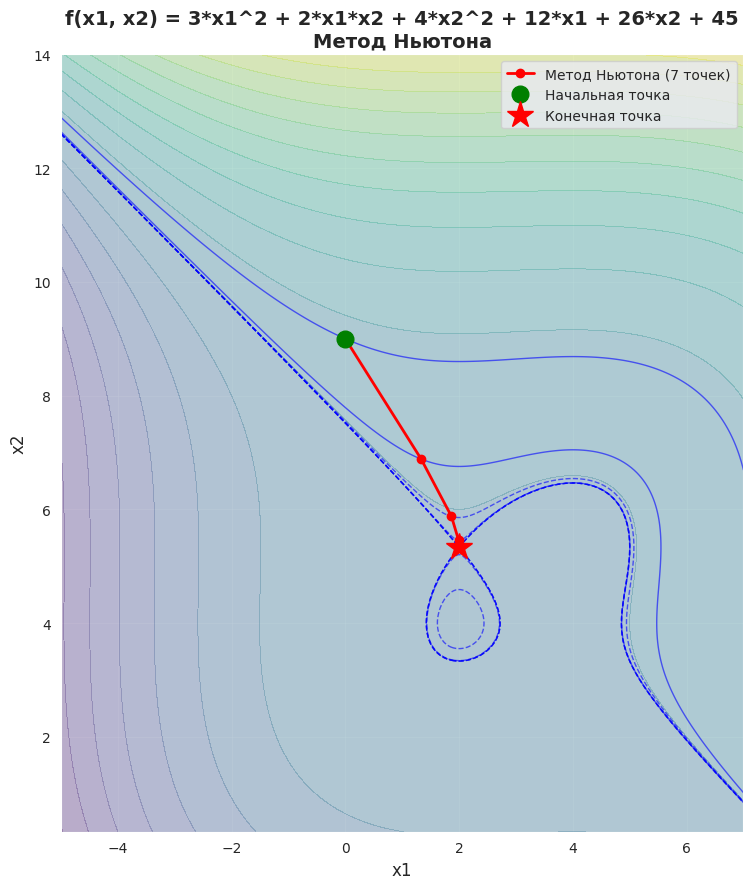

In [20]:
x0: NDArray[np.float64] = np.array([0, 9], dtype=np.float64)
method_newton: NewtonMethod = NewtonMethod(eps=1e-4, max_iterations=100)
history_newton: OptimizationHistory = method_newton(func, x0)
Visualizer.visualize_method(history_newton, method_newton.name, func, None)

## ДЗ2.3: Объектная модель методов оптимизации

In [16]:
class Optimizer:
    """
    Класс-фасад для выполнения оптимизации
    Использует композицию: содержит функцию и методы оптимизации
    """
    
    def __init__(self, func: MathematicalFunction) -> None:
        self.func: MathematicalFunction = func
        self.methods: List[OptimizationMethod] = []
        self.results: Dict[str, OptimizationHistory] = {}
    
    def add_method(self, method: OptimizationMethod) -> None:
        """Добавить метод оптимизации (Dependency Injection)"""
        self.methods.append(method)
    
    def optimize_all(self, x0: NDArray[np.float64]) -> Dict[str, OptimizationHistory]:
        """Выполнить оптимизацию всеми методами"""
        results: Dict[str, OptimizationHistory] = {}
        for method in self.methods:
            history = method(self.func, x0)
            results[method.name] = history
        self.results = results
        return results
    
    def print_results(self) -> None:
        """Вывести результаты всех методов"""
        print('\nРезультаты оптимизации:')
        
        for method_name, history in self.results.items():
            final_point: NDArray[np.float64] = history.get_final_point()
            final_f: float = history.f_history[-1]
            final_grad: NDArray[np.float64] = history.grad_history[-1]
            
            print(f'{method_name}: x* = ({final_point[0]:.6f}, {final_point[1]:.6f}), f(x*) = {final_f:.6f}, ||grad|| = {np.linalg.norm(final_grad):.6e}, итер = {history.iterations}')

In [17]:
func_obj: MathematicalFunction = Func1()
optimizer: Optimizer = Optimizer(func_obj)

optimizer.add_method(CoordinateDescentMethod(eps=1e-4, max_iterations=100))
optimizer.add_method(GradientDescentMethod(alpha=0.05, eps=1e-4, max_iterations=100))
optimizer.add_method(SteepestDescentMethod(eps=1e-4, max_iterations=100))

x0_obj: NDArray[np.float64] = np.array([2.0, 4.0], dtype=np.float64)
results_obj: Dict[str, OptimizationHistory] = optimizer.optimize_all(x0_obj)

optimizer.print_results()



Результаты оптимизации:
Покоординатный спуск: x* = (-1.007304, -2.995049), f(x*) = 0.000186, ||grad|| = 4.214084e-02, итер = 201
Градиентный спуск: x* = (-1.000014, -2.999992), f(x*) = 0.000000, ||grad|| = 7.689489e-05, итер = 42
Наискорейший спуск: x* = (-1.000003, -2.999998), f(x*) = 0.000000, ||grad|| = 1.860524e-05, итер = 6
